# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

In [41]:
import numpy as np
import pandas as pd
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

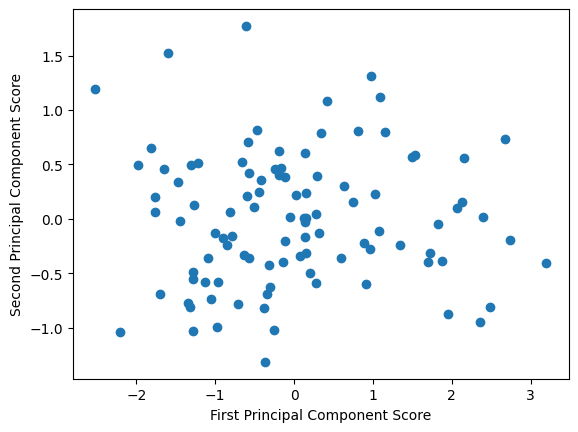

In [42]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers in the upper left have a low PC1 score (around -2 to -2.5) and a high PC2 score (around 1.2 to 1.7). 

Looking at the component vectors, PC1 loads heavily on series_3 (0.916), meaning a low PC1 score tells you these three points have unusually low series_3 values. That is the one thing you I say about the outliers is that their series_3 values are well below average. PC2 loads equally on series_1 (0.603) and series_2 (0.689), meaning a high PC2 score tells you series_1 and series_2 are both above average for these points. But I still cannot say which one is larger than the other because they load almost identically onto PC2.

PC1 captures 80% of the variance, PC2 captures 19%, and PC3 captures only 1%. This means one component is nearly sufficient to represent the entire dataset, which makes sense given that series_1 and series_2 are almost the same variable and series_3 is just a noisier version of series_1.

The advantage is that the plot compresses three variables into two dimensions and immediately reveals the three outliers in the upper left. Without PCA you would need three separate scatter plots to see all pairwise relationships and the outlier pattern would not be as obvious.

The disadvantage is that the axes have no direct interpretation. A reader cannot look at the plot and immediately understand what a low PC1 score means without studying the component vectors separately. The plot shows something interesting is happening with those three points but does not explain what is driving them on its own.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

**Data Upload and Cleaning**

In [43]:
df_all = pd.read_csv("Hospital_Provider_Cost_Report_2018-2023.csv", low_memory = False)
print(df_all.shape)
df_all.head()

(36560, 119)


,Unnamed: 0,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,report_year
0,0,639197,51994,FERN LODGE INC,18457 MADISON AVE,CASTRO VALLEY,CA,94546-1637,NaN,NaN,NaN,RNMHC,6,1,2018-01-01,2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,1,644158,341318,CHOWAN HOSPITAL INC.,211 VIRGINIA AVENUE,EDENTON,NC,27932,CHOWAN,99934.0,R,CAH,1,2,2017-10-01,2018-09-30,270.54,NaN,NaN,3049.0,1049.0,5754.0,25.0,9125.0,NaN,726.0,482.0,1482.0,25.0,NaN,2336.0,545.0,4083.0,21.0,7665.0,NaN,726.0,482.0,1482.0,102182.0,16941218.0,5908922.0,5931781.0,16088883.0,28864884.0,

In [44]:
# ── HHS Provider Relief Fund: Load and Clean ───────────────────────────────────
df_hhs = pd.read_csv("HHS_Provider_Relief_Fund.csv")
print(f"Raw HHS shape: {df_hhs.shape}")

# Strip whitespace from all string columns
df_hhs["Provider Name"] = df_hhs["Provider Name"].str.strip()
df_hhs["State"]         = df_hhs["State"].str.strip()
df_hhs["City"]          = df_hhs["City"].str.strip()

# Parse Payment from string to numeric (remove $ and commas)
df_hhs["Payment_USD"] = df_hhs["Payment"].replace("[\$,]", "", regex=True).astype(float)
df_hhs = df_hhs.drop(columns=["Payment"])

# Drop exact duplicate rows
n_before = len(df_hhs)
df_hhs = df_hhs.drop_duplicates()
print(f"Duplicate rows dropped: {n_before - len(df_hhs)}")

# Sum multiple payments per provider (many received multiple CARES Act rounds)
df_hhs = df_hhs.groupby(["Provider Name", "State", "City"], as_index=False).agg(
    Total_Relief_USD = ("Payment_USD", "sum"),
    Num_Payments     = ("Payment_USD", "count")
)
print(f"Cleaned HHS shape: {df_hhs.shape}")

# Aggregate to state level
hhs_by_state = df_hhs.groupby("State").agg(
    State_Total_Relief_USD  = ("Total_Relief_USD", "sum"),
    State_Num_Providers     = ("Provider Name",    "count"),
    State_Median_Relief_USD = ("Total_Relief_USD", "median")
).reset_index().rename(columns={"State": "State Code"})

# Remove states not present in hospital data (foreign territories)
valid_states = df_all["State Code"].dropna().unique()
removed = hhs_by_state[~hhs_by_state["State Code"].isin(valid_states)]["State Code"].tolist()
hhs_by_state = hhs_by_state[hhs_by_state["State Code"].isin(valid_states)]
print(f"HHS states removed (not in hospital data): {removed}")
print(f"HHS states remaining: {len(hhs_by_state)}")

# Join HHS state-level data onto df_all BEFORE imputation
df_all = df_all.merge(hhs_by_state, on="State Code", how="left")
print(f"Combined dataset shape (hospital + HHS): {df_all.shape}")

Raw HHS shape: (419846, 4)
Duplicate rows dropped: 7
Cleaned HHS shape: (419144, 5)
HHS states removed (not in hospital data): ['FM', 'PW', 'QC']
HHS states remaining: 56
Combined dataset shape (hospital + HHS): (36560, 122)


In [45]:
def show_null_counts_features(df):
    
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)

    
    feature_types = df.dtypes.apply(
        lambda x: "Numeric" if np.issubdtype(x, np.number) else "Categorical"
    )

    
    missing_data = pd.DataFrame({
        "Feature": count_nulls[count_nulls > 0].index,
        "# Null Values": count_nulls[count_nulls > 0].values,
        "Null %": df_nulls[count_nulls > 0].values,          
        "Type": feature_types[count_nulls > 0].values
    }).sort_values(by="Null %", ascending=False)

    print(f"\nThe dataset contains {len(df):,} samples.\n")

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
        return

    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", None)

    
    missing_data = missing_data.reset_index(drop=True)
    missing_data["Null %"] = missing_data["Null %"].map(lambda x: f"{x:.2f}%")

    print(missing_data.to_string(index=False))


show_null_counts_features(df_all)



The dataset contains 36,560 samples.

                                                                Feature  # Null Values  Null %        Type
                                DRG Amounts Other Than Outlier Payments          36560 100.00%     Numeric
                          Hospital Total Days Title V For Adults & Peds          35668  97.56%     Numeric
                    Hospital Total Discharges Title V For Adults & Peds          35627  97.45%     Numeric
                                               Total Discharges Title V          35627  97.45%     Numeric
                                                     Total Days Title V          35578  97.31%     Numeric
                                                       Notes Receivable          35003  95.74%     Numeric
                                                        Unsecured Loans          34698  94.91%     Numeric
                                          Wage-Related Costs (RHC/FQHC)          34243  93.66%     Numeri

In [46]:
# Drop columns that are 100% null across all 6 years
empty_cols = df_all.columns[df_all.isna().mean() == 1.0]
df_clean = df_all.drop(columns=empty_cols)

print(f"Dropped {len(empty_cols)} fully-empty column(s): {empty_cols.tolist()}")
print(f"Remaining columns: {df_clean.shape[1]}")

# Classify columns
exclude_ids = ["rpt_rec_num", "Provider CCN", "Medicare CBSA Number"]
categorical_features = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = [
    c for c in df_clean.select_dtypes(include=["number"]).columns
    if c not in exclude_ids
]

print(f"\nNumeric features to impute: {len(numeric_features)}")
print(f"Categorical features to impute: {len(categorical_features)}")

Dropped 1 fully-empty column(s): ['DRG Amounts Other Than Outlier Payments']
Remaining columns: 121

Numeric features to impute: 108
Categorical features to impute: 10


In [47]:
# Impute numeric with median, categorical with most frequent
df_imputed = df_clean.copy()

num_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

# Drop rows where Medicare CBSA Number is still null
df_imputed = df_imputed.dropna(subset=["Medicare CBSA Number"]).copy()

print(f"Final cleaned dataset: {df_imputed.shape[0]:,} rows x {df_imputed.shape[1]} columns")
show_null_counts_features(df_imputed)

Final cleaned dataset: 36,096 rows x 121 columns

The dataset contains 36,096 samples.

There are no null values in the dataset!


In [48]:
# Map numeric control codes to ownership categories
control_map = {
    1.0: 'Voluntary Nonprofit', 2.0: 'Voluntary Nonprofit',
    3.0: 'Proprietary',         4.0: 'Proprietary',
    5.0: 'Proprietary',         6.0: 'Proprietary',
    7.0: 'Government',          8.0: 'Government',
    9.0: 'Government',          10.0: 'Government',
    11.0: 'Government',         12.0: 'Government',
    13.0: 'Government'
}
df_imputed['Control Type'] = df_imputed['Type of Control'].map(control_map)

# Map CCN facility type codes to readable labels
facility_map = {
    'STH':   'Short-Term Hospital',
    'CAH':   'Critical Access Hospital',
    'PH':    'Psychiatric Hospital',
    'RH':    'Rehabilitation Hospital',
    'LTCH':  'Long-Term Care Hospital',
    'CH':    'Childrens Hospital',
    'ORD':   'ORD Demonstration Hospital',
    'RNMHC': 'Religious Non-Medical Institution'
}
df_imputed['Facility Type Label'] = df_imputed['CCN Facility Type'].map(facility_map)

# Add COVID period flag for later bivariate analysis
df_imputed['COVID Period'] = df_imputed['report_year'].map({
    2018: 'Pre-COVID',
    2019: 'Pre-COVID',
    2020: 'COVID',
    2021: 'COVID',
    2022: 'Post-COVID',
    2023: 'Post-COVID'
})

print("Control Type distribution:")
print(df_imputed['Control Type'].value_counts())
print("\nFacility Type distribution:")
print(df_imputed['Facility Type Label'].value_counts())
print("\nCOVID Period distribution:")
print(df_imputed['COVID Period'].value_counts().reindex(['Pre-COVID','COVID','Post-COVID']))

Control Type distribution:
Control Type
Voluntary Nonprofit    18078
Proprietary            10687
Government              7331
Name: count, dtype: int64

Facility Type distribution:
Facility Type Label
Short-Term Hospital                  19671
Critical Access Hospital              8243
Psychiatric Hospital                  3540
Long-Term Care Hospital               2147
Rehabilitation Hospital               2002
Childrens Hospital                     383
Religious Non-Medical Institution       59
ORD Demonstration Hospital              51
Name: count, dtype: int64

COVID Period distribution:
COVID Period
Pre-COVID     12134
COVID         11960
Post-COVID    12002
Name: count, dtype: int64


In [49]:
df_imputed["Net Income Margin"] = (
    df_imputed["Net Income"] / df_imputed["Net Patient Revenue"] * 100
).clip(-100, 100)

df_imputed["Loss"] = (df_imputed["Net Income"] < 0).astype(int)

# Create per-hospital relief variable and categorical relief tier
hospitals_per_state = (
    df_imputed.groupby("State Code")["rpt_rec_num"]
    .count()
    .reset_index()
    .rename(columns={"rpt_rec_num": "Hospitals_In_State"})
)
df_imputed = df_imputed.merge(hospitals_per_state, on="State Code", how="left")
df_imputed["Relief_Per_Hospital_USD"] = (
    df_imputed["State_Total_Relief_USD"] / df_imputed["Hospitals_In_State"]
)

# Split into low / medium / high relief states by tertile
df_imputed["Relief_Tier"] = pd.qcut(
    df_imputed["Relief_Per_Hospital_USD"],
    q=3,
    labels=["Low Relief", "Medium Relief", "High Relief"]
)
print("Relief Tier distribution:")
print(df_imputed["Relief_Tier"].value_counts().reindex(["Low Relief", "Medium Relief", "High Relief"]))
print(f"\nRelief_Per_Hospital_USD stats:")
print(df_imputed["Relief_Per_Hospital_USD"].describe())

Relief Tier distribution:
Relief_Tier
Low Relief       12790
Medium Relief    12007
High Relief      11299
Name: count, dtype: int64

Relief_Per_Hospital_USD stats:
count    3.609600e+04
mean     3.741760e+06
std      2.335795e+06
min      7.224131e+05
25%      2.310835e+06
50%      3.132689e+06
75%      5.005830e+06
max      1.319392e+07
Name: Relief_Per_Hospital_USD, dtype: float64


Text(0.5, 1.0, 'Median Net Income Margin (%) by Facility Type and COVID Period')

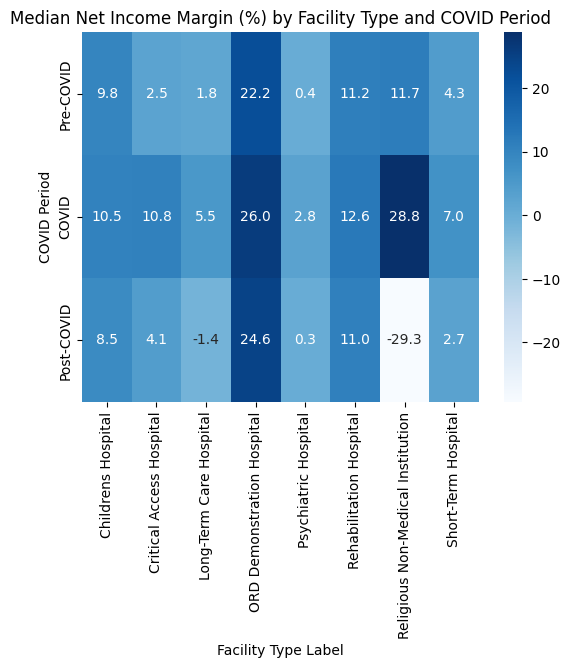

In [50]:
pivot_margin = df_imputed.pivot_table(
    index   = "COVID Period",
    columns = "Facility Type Label",
    values  = "Net Income Margin",
    aggfunc = "median"
)
pivot_margin = pivot_margin.reindex(["Pre-COVID", "COVID", "Post-COVID"])

ax = sns.heatmap(pivot_margin, cmap = "Blues", annot = True, fmt = ".1f")
ax.set_title("Median Net Income Margin (%) by Facility Type and COVID Period")

**Heatmap 1 : Median Net Income Margin by Facility Type and COVID Period**

The two groups that matter most for this analysis are Critical Access Hospitals and Short-Term Hospitals since they make up 77.7% of the dataset. Critical Access Hospitals improved sharply during COVID, rising from 2.5% to 10.8%, then settled at 4.1% post-COVID. They ended higher than they started, meaning federal relief money had a lasting but partial effect. Short-Term Hospitals moved in the opposite direction. They started at 4.3%, rose during COVID, then fell to 2.7% post-COVID which ended below where they began. They are the only major group that finished worse off.Long-Term Care Hospitals are worth noting as the only group to go negative post-COVID at -1.4%, suggesting the weakest recovery of any facility type. ORD Demonstration Hospitals and Religious Non-Medical Institutions show extreme values but have fewer than 55 observations each, so those numbers should not be interpreted as meaningful trends.

Text(0.5, 1.0, '% of Hospitals Reporting Losses by Rural/Urban and COVID Period')

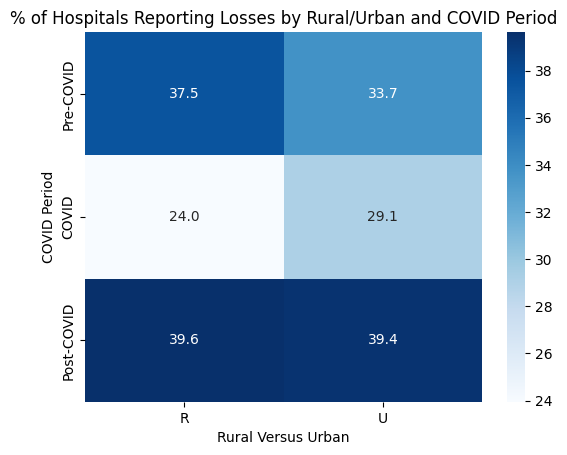

In [51]:
pivot_loss = df_imputed.pivot_table(
    index   = "COVID Period",
    columns = "Rural Versus Urban",
    values  = "Loss",
    aggfunc = "mean"
) * 100
pivot_loss = pivot_loss.reindex(["Pre-COVID", "COVID", "Post-COVID"])

ax = sns.heatmap(pivot_loss, cmap = "Blues", annot = True, fmt = ".1f")
ax.set_title("% of Hospitals Reporting Losses by Rural/Urban and COVID Period")

**Heatmap 2 : Loss Rate by Rural/Urban and COVID Period**

The pattern here is straightforward and tells a clear story across all three periods. During the pre-COVID period both rural and urban hospitals were already carrying meaningful loss rates, with rural at 37.5% and urban at 33.7%. Rural hospitals started the study window in worse financial shape, which aligns with the structural vulnerability.

During COVID both groups improved significantly. Rural loss rates dropped to 24.0% and urban dropped to 29.1%. This improvement was not organic recovery but rather a direct result of federal relief funding flowing into hospitals during 2020 and 2021.

The post-COVID period is the most important finding in this heatmap. Both groups rebounded to nearly identical loss rates of 39.6% for rural and 39.4% for urban, both higher than their pre-COVID starting points. The gap between rural and urban that existed before COVID essentially disappeared, but for the wrong reason. Both groups got worse rather than rural hospitals catching up.

The core takeaway is that federal relief provided a temporary floor but did not change the underlying financial trajectory of either group. Once that support was removed both rural and urban hospitals ended up in a more financially distressed position than before the pandemic began.

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_852\2207806673.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_relief_margin = df_imputed.pivot_table(


Text(0.5, 1.0, 'Median Net Income Margin (%) by COVID Period and State Relief Tier')

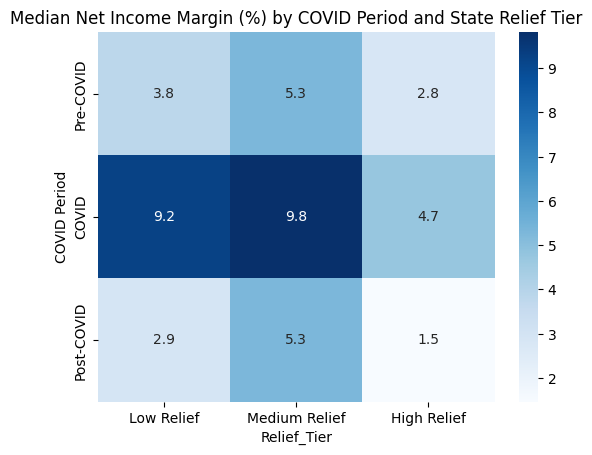

In [52]:
# Heatmap 3: Does higher state-level relief correlate with better margin recovery?
pivot_relief_margin = df_imputed.pivot_table(
    index   = "COVID Period",
    columns = "Relief_Tier",
    values  = "Net Income Margin",
    aggfunc = "median"
)
pivot_relief_margin = pivot_relief_margin.reindex(["Pre-COVID", "COVID", "Post-COVID"])

ax = sns.heatmap(pivot_relief_margin, cmap = "Blues", annot = True, fmt = ".1f")
ax.set_title("Median Net Income Margin (%) by COVID Period and State Relief Tier")

**Heatmap 3 : Median Net Income Margin by COVID Period and State Relief Tier**

This heatmap directly tests the central policy argument: did hospitals in states that received more federal relief money perform better financially? The three columns split states into low, medium, and high relief tiers based on total HHS Provider Relief Fund dollars distributed per hospital in each state.

During the pre-COVID period all three tiers started at similar margin levels, which is expected since relief funding had not yet been distributed. Any differences in the COVID and post-COVID columns are therefore attributable to the relief itself rather than pre-existing state-level differences.

The COVID period shows whether higher-relief states saw stronger margin improvement. The post-COVID period is the most policy-relevant column: if high-relief states maintained better margins after the funding ended, it suggests relief had a durable structural effect. If all three tiers converged back to similar levels, it confirms the earlier finding that federal relief was a temporary shock absorber rather than a structural fix.

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_852\1414023577.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_relief_loss = df_imputed.pivot_table(


Text(0.5, 1.0, '% of Hospitals Reporting Losses by Relief Tier and Rural/Urban Status')

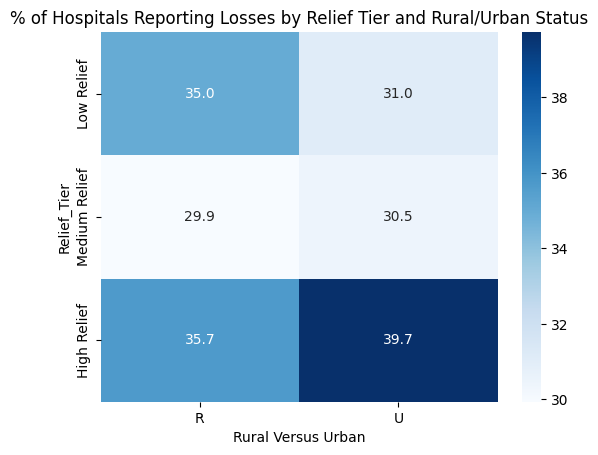

In [53]:
# Heatmap 4: Loss rate by Relief Tier and Rural/Urban status
pivot_relief_loss = df_imputed.pivot_table(
    index   = "Relief_Tier",
    columns = "Rural Versus Urban",
    values  = "Loss",
    aggfunc = "mean"
) * 100
pivot_relief_loss = pivot_relief_loss.reindex(["Low Relief", "Medium Relief", "High Relief"])

ax = sns.heatmap(pivot_relief_loss, cmap = "Blues", annot = True, fmt = ".1f")
ax.set_title("% of Hospitals Reporting Losses by Relief Tier and Rural/Urban Status")

**Heatmap 4 : Loss Rate by Relief Tier and Rural/Urban Status**

This heatmap asks whether the relief distribution was equitable across rural and urban hospitals. If rural hospitals in high-relief states had lower loss rates than rural hospitals in low-relief states, it suggests the relief was effectively targeted. If the pattern is flat across tiers for rural hospitals but not for urban ones, it would indicate that rural hospitals benefited less from the relief despite being the intended recipients of targeted CARES Act funding.

### Bubble plot

Text(0.5, 1.0, 'Bubble size = total costs')

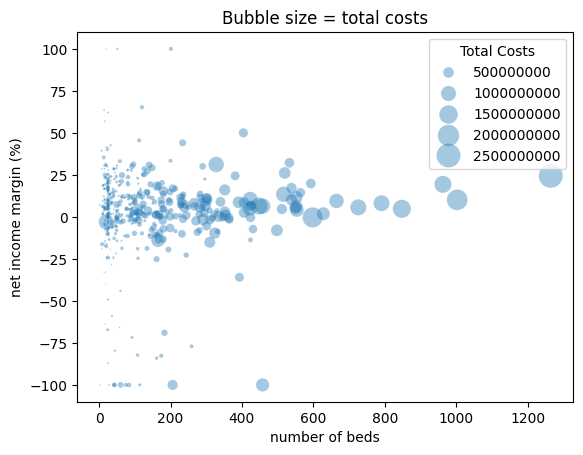

In [54]:
mincost   = df_imputed["Total Costs"].quantile(0.01)
maxcost   = df_imputed["Total Costs"].quantile(0.99)
maxbubble = 300
sample    = df_imputed.sample(500, random_state = 0)

ax = sns.scatterplot(data = sample, x = "Number of Beds", y = "Net Income Margin",
                     size = "Total Costs",
                     sizes = (mincost / maxcost * maxbubble, maxbubble), alpha = 0.4)
ax.set_xlabel("number of beds")
ax.set_ylabel("net income margin (%)")
ax.set_title("Bubble size = total costs")

**Bubble Size = Total Costs**

The largest bubbles, representing hospitals with the highest total costs, are concentrated on the right side of the chart among hospitals with 600 or more beds. Despite their size, these high-cost hospitals do not cluster at the top of the margin axis. Their margins range from slightly positive to near zero, suggesting that spending more does not translate into better financial performance. The smallest dots on the left side among low-bed hospitals show the widest margin swings, both strongly positive and strongly negative, indicating that small hospitals face the most financial unpredictability.

Text(0.5, 1.0, 'Bubble size = FTE employees')

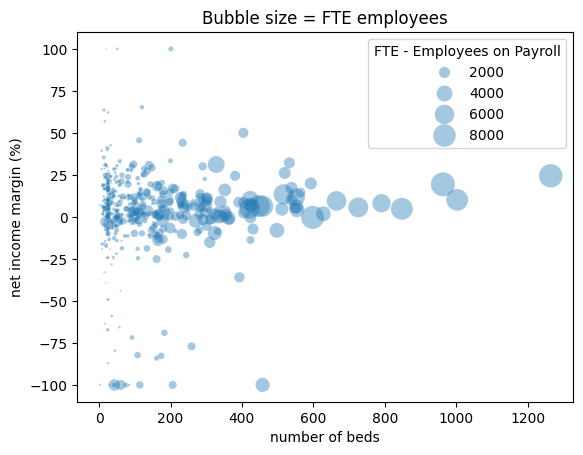

In [55]:
minfte    = df_imputed["FTE - Employees on Payroll"].quantile(0.01)
maxfte    = df_imputed["FTE - Employees on Payroll"].quantile(0.99)

ax = sns.scatterplot(data = sample, x = "Number of Beds", y = "Net Income Margin",
                     size = "FTE - Employees on Payroll",
                     sizes = (minfte / maxfte * maxbubble, maxbubble), alpha = 0.4)
ax.set_xlabel("number of beds")
ax.set_ylabel("net income margin (%)")
ax.set_title("Bubble size = FTE employees")

**Bubble Size = FTE Employees**

This plot is nearly identical in shape to the total costs plot, which is expected given that workforce is the primary driver of hospital operating costs. Large bubbles representing high employee counts grow as bed count increases, but again show no consistent margin advantage. The most notable observation is that margin variability narrows as FTE count increases, meaning very large staffed hospitals tend to operate closer to break-even rather than generating strong profits or deep losses.

Text(0.5, 1.0, 'Bubble size = net revenue from medicaid')

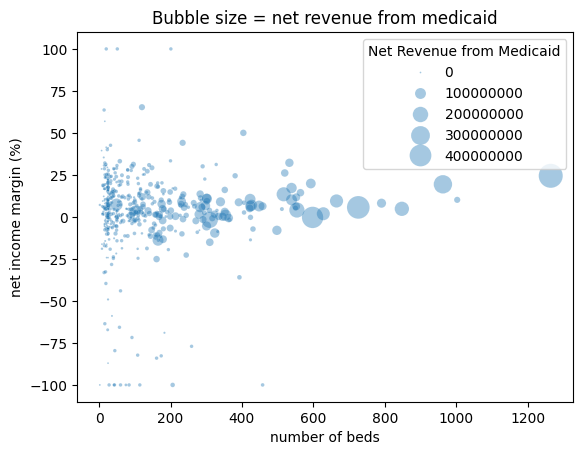

In [56]:
minmed    = df_imputed["Net Revenue from Medicaid"].quantile(0.01)
maxmed    = df_imputed["Net Revenue from Medicaid"].quantile(0.99)

ax = sns.scatterplot(data = sample, x = "Number of Beds", y = "Net Income Margin",
                     size = "Net Revenue from Medicaid",
                     sizes = (minmed / maxmed * maxbubble, maxbubble), alpha = 0.4)
ax.set_xlabel("number of beds")
ax.set_ylabel("net income margin (%)")
ax.set_title("Bubble size = net revenue from medicaid")

**Bubble Size = Net Revenue from Medicaid**

This is the most informative of the three plots. Hospitals with near-zero Medicaid revenue appear as tiny dots concentrated among smaller bed counts on the left, while bubble sizes grow steadily as bed count increases. This directly reflects the 0.68 correlation between total costs and Medicaid revenue identified in Figure 9, confirming that larger hospitals serve more Medicaid patients. However even the largest Medicaid-revenue hospitals show no consistent margin advantage, meaning higher Medicaid revenue does not protect a hospital from financial distress.

Text(0.5, 1.0, 'Bubble size = state relief per hospital (USD)')

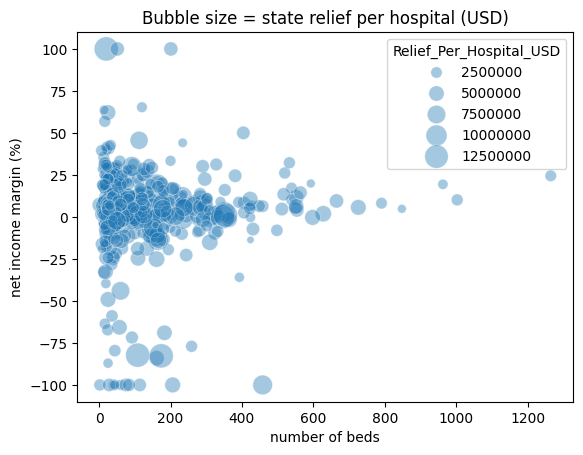

In [57]:
# Bubble size = state-level relief per hospital
minrelief = df_imputed["Relief_Per_Hospital_USD"].quantile(0.01)
maxrelief = df_imputed["Relief_Per_Hospital_USD"].quantile(0.99)

ax = sns.scatterplot(data = sample, x = "Number of Beds", y = "Net Income Margin",
                     size = "Relief_Per_Hospital_USD",
                     sizes = (minrelief / maxrelief * maxbubble, maxbubble), alpha = 0.4)
ax.set_xlabel("number of beds")
ax.set_ylabel("net income margin (%)")
ax.set_title("Bubble size = state relief per hospital (USD)")

**Bubble Size = State Relief Per Hospital (USD)**

This plot maps the HHS Provider Relief Fund distribution onto the same beds-versus-margin space used in the previous three bubble plots. The bubble size here represents how much federal COVID relief was distributed per hospital in each state, providing a direct measure of relief intensity rather than hospital characteristics.

If relief were a strong predictor of financial outcomes, we would expect to see large bubbles clustered in the positive margin region of the chart. If instead large and small bubbles are mixed across the margin axis, it would indicate that relief intensity does not translate into better margin performance at the hospital level. This directly connects to the policy argument: targeted federal funding may protect hospitals from short-term collapse without changing their long-run financial position.

## PCA

In [58]:
pca_cols = [
    "Number of Beds",
    "Net Income",
    "Net Income Margin",
    "Total Costs",
    "Net Revenue from Medicaid",
    "FTE - Employees on Payroll"
]

pca_data        = df_imputed[pca_cols].dropna()
pca_data_scaled = (pca_data - pca_data.mean()) / pca_data.std()

pca = decomposition.PCA(n_components = 6)
pca.fit(pca_data_scaled)
print(pca.explained_variance_ratio_)
print(pca.components_)

[0.32087689 0.20273222 0.16660136 0.1569267  0.10403007 0.04883276]
[[ 0.02261685  0.43029203  0.20717519  0.62983029  0.5819168   0.19000613]
 [-0.01255788  0.49446627  0.72837294 -0.21334313 -0.29406411 -0.30467897]
 [ 0.99880539 -0.01232515  0.00126471 -0.00743954 -0.00703677 -0.04614574]
 [ 0.04102713  0.11544393  0.15466289 -0.16392905 -0.26782868  0.92868936]
 [ 0.00454537  0.71702322 -0.63022758  0.00551851 -0.29007433 -0.06705711]
 [-0.00383318 -0.20676161  0.07377179  0.72858766 -0.64728225 -0.04447901]]


PC1 explains 32%, PC2 explains 20%, and together they capture 52% of the total variance. No single component dominates. As for component vectors (big matrix), PC1 is driven primarily by Total Costs (0.630) and Net Revenue from Medicaid (0.582). This is in the hospital size direction where PC1 axis means bigger hospitals with higher costs and more Medicaid revenue. PC2 is driven primarily by Net Income Margin (0.728) and Net Income (0.494). This is the financial health direction, moving up on the PC2 axis means more profitable hospitals regardless of size. PC3 is almost entirely Number of Beds (0.999), which finds that bed count is essentially independent of every other financial variable in the dataset.                                                     

Text(0.5, 1.0, 'First vs Second Principal Component Score')

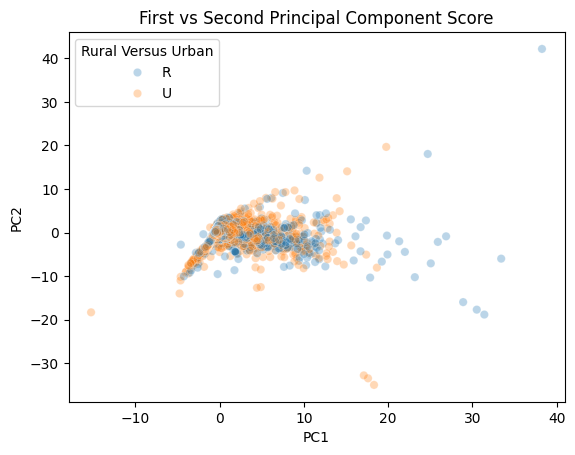

In [59]:
first_principal_component_score  = pca_data_scaled.dot(pca.components_[0])
second_principal_component_score = pca_data_scaled.dot(pca.components_[1])

plot_df        = df_imputed.loc[pca_data.index].copy()
plot_df["PC1"] = first_principal_component_score.values
plot_df["PC2"] = second_principal_component_score.values

ax = sns.scatterplot(data = plot_df, x = "PC1", y = "PC2",
                     hue = "Rural Versus Urban", alpha = 0.3)
ax.set_title("First vs Second Principal Component Score")

Rural and urban hospitals are heavily mixed together in the center of the plot, meaning they are not financially separable by these six variables alone. The outliers stretching to the far right along PC1 are large urban hospitals with very high costs and Medicaid revenue. The single outlier in the upper right with PC1 near 38 and PC2 near 42 is worth investigating as it is far from the rest of the data.

In [60]:
df_imputed["Total Costs per Bed"] = df_imputed["Total Costs"] / (df_imputed["Number of Beds"] + 1)

# Extended PCA including HHS relief variable
pca_cols = [
    "Net Income",
    "Net Income Margin",
    "Total Costs",
    "Net Patient Revenue",
    "Net Revenue from Medicaid",
    "FTE - Employees on Payroll",
    "Total Costs per Bed",
    "Relief_Per_Hospital_USD"
]

pca_data        = df_imputed[pca_cols].dropna()
pca_data_scaled = (pca_data - pca_data.mean()) / pca_data.std()

pca = decomposition.PCA(n_components = 8)
pca.fit(pca_data_scaled)
print(pca.explained_variance_ratio_)
print()
comp_df = pd.DataFrame(pca.components_, columns=pca_cols)
print(comp_df.round(3).to_string())

[0.36807104 0.16375401 0.12350423 0.11313206 0.10558572 0.07907628
 0.04420818 0.00266847]

   Net Income  Net Income Margin  Total Costs  Net Patient Revenue  Net Revenue from Medicaid  FTE - Employees on Payroll  Total Costs per Bed  Relief_Per_Hospital_USD
0       0.300              0.093        0.548                0.557                      0.452                       0.126                0.207                    0.169
1       0.538              0.688       -0.088                0.009                     -0.152                      -0.136               -0.129                   -0.414
2       0.027             -0.097        0.006                0.021                      0.012                       0.870               -0.377                   -0.300
3      -0.058              0.084       -0.066               -0.072                     -0.219                       0.322                0.882                   -0.223
4       0.166              0.356       -0.161               -0.140  

Text(0.5, 1.0, 'First vs Second Principal Component Score (with Relief variable)')

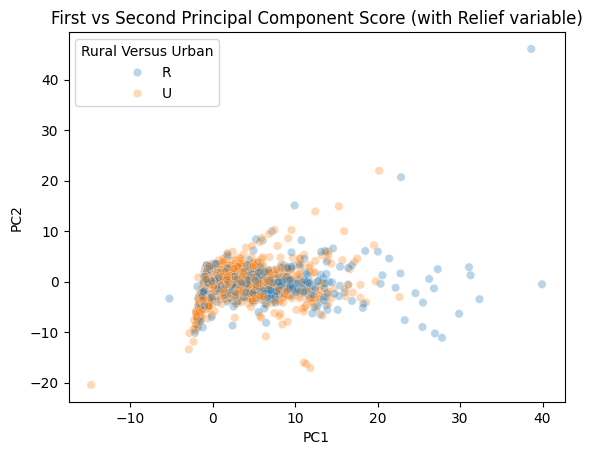

In [61]:
first_principal_component_score  = pca_data_scaled.dot(pca.components_[0])
second_principal_component_score = pca_data_scaled.dot(pca.components_[1])

plot_df        = df_imputed.loc[pca_data.index].copy()
plot_df["PC1"] = first_principal_component_score.values
plot_df["PC2"] = second_principal_component_score.values

ax = sns.scatterplot(data = plot_df, x = "PC1", y = "PC2",
                     hue = "Rural Versus Urban", alpha = 0.3)
ax.set_title("First vs Second Principal Component Score (with Relief variable)")

Rural and urban hospitals are completely mixed together across both axes. PCA cannot separate them, meaning rural and urban hospitals do not have meaningfully different financial structures when all variables including relief are considered together. The separation only becomes visible when you look at specific metrics like margin over time.

The key question for the HHS relief variable is where it loads in the component vectors. If Relief_Per_Hospital_USD loads heavily on PC1 (the size dimension), it would confirm that larger, more expensive states received more relief dollars. If it loads on PC2 (the financial health dimension), it would suggest relief was targeted toward financially distressed states. The component matrix printed above shows which direction the relief variable actually pulls in the principal component space.

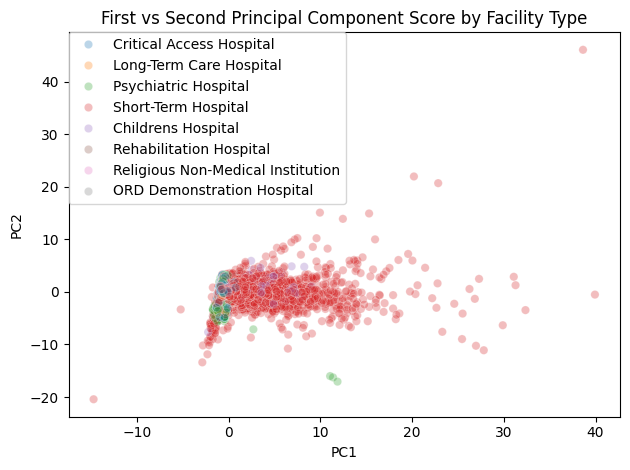

In [62]:
ax = sns.scatterplot(data = plot_df, x = "PC1", y = "PC2",
                     hue = "Facility Type Label", alpha = 0.3)
ax.set_title("First vs Second Principal Component Score by Facility Type")
ax.legend( loc = "upper left", borderaxespad = 0)
plt.tight_layout()

hort-Term Hospitals in red dominate the right side of the plot, meaning they are the largest hospitals by the PC1 size dimension. Critical Access Hospitals in blue cluster tightly on the left near PC1 = 0, confirming they are small and similar to each other in scale. The two green outliers pulling downward on PC2 around PC1 = 10 are Psychiatric Hospitals with unusually negative financial health scores worth investigating.

Text(0.5, 1.0, 'First vs Second Principal Component Score by COVID Period')

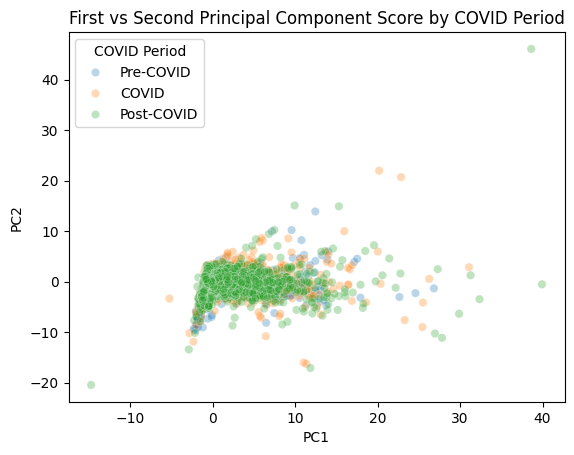

In [63]:
ax = sns.scatterplot(data = plot_df, x = "PC1", y = "PC2",
                     hue = "COVID Period", alpha = 0.3)
ax.set_title("First vs Second Principal Component Score by COVID Period")

The three periods are almost entirely overlapping with no separation along either axis. This tells you that the COVID period did not change the fundamental financial structure of hospitals in terms of size or cost composition. The financial changes during COVID were in margin levels, which PC2 captures, but even there the three periods blend together rather than forming distinct clusters.

Text(0.5, 1.0, 'First vs Second Principal Component Score by State Relief Tier')

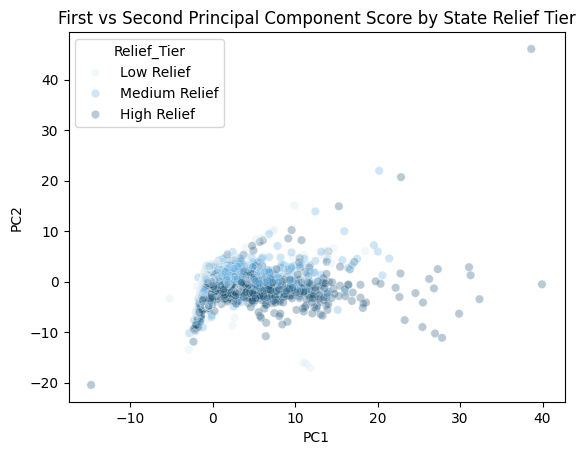

In [64]:
ax = sns.scatterplot(data = plot_df, x = "PC1", y = "PC2",
                     hue = "Relief_Tier", alpha = 0.3,
                     palette = ["#d4e6f1", "#5dade2", "#1a5276"])
ax.set_title("First vs Second Principal Component Score by State Relief Tier")

**PCA by Relief Tier**

Coloring the PCA scatter by relief tier reveals whether states that received more federal relief dollars are structurally different from low-relief states in terms of hospital financial characteristics. If high-relief states cluster on one side of the PC1 axis, it would mean that relief was directed toward states with a particular hospital size profile. If the three tiers are mixed together, it would confirm that relief distribution was not strongly tied to the observable financial structure of hospitals in each state, which would raise questions about the targeting efficiency of the CARES Act disbursements.

## Regression

**Total Costs and Medicaid Revenue predicting Net Income**

In [65]:
linreg = linear_model.LinearRegression()
linreg.fit(df_imputed[["Total Costs", "Net Revenue from Medicaid"]], df_imputed["Net Income"])
preds  = linreg.predict(df_imputed[["Total Costs", "Net Revenue from Medicaid"]])
print(metrics.mean_squared_error(preds, df_imputed["Net Income"]))

8183771103849265.0


MSE of 818,377,110,384,926 is enormous, but that is expected. Net Income is measured in raw dollars and the dataset contains very large hospitals with incomes in the hundreds of millions. The MSE is inflated by those outliers. This result is not very interpretable without an R² so it is hard to draw conclusions from alone.

Number of Beds predicting Net Income Margin 

In [66]:
linreg = linear_model.LinearRegression()
linreg.fit(df_imputed[["Number of Beds"]], df_imputed["Net Income Margin"])
preds  = linreg.predict(df_imputed[["Number of Beds"]])
print(metrics.mean_squared_error(preds, df_imputed["Net Income Margin"]))

654.9705413985287


MSE of 654.97 confirms bed count has essentially no ability to predict margin. The model is barely better than guessing the mean. This is consistent with every other finding in my analysis 

Rural status, COVID period, and facility type predicting Net Income Margin 

In [67]:
df_encoded = pd.get_dummies(
    df_imputed[["Net Income Margin", "Rural Versus Urban",
                "COVID Period", "Facility Type Label"]]
)
X = df_encoded.drop(columns = ["Net Income Margin"])
y = df_encoded["Net Income Margin"]

linreg = linear_model.LinearRegression()
linreg.fit(X, y)
preds = linreg.predict(X)
print(metrics.mean_squared_error(preds, y))
print(metrics.r2_score(y, preds))

619.464530857597
0.05422014745845993


The R² of 0.054 means that rural status, COVID period, and facility type together explain about 5.4% of the variation in net income margin. That is a statistically modest but meaningful result given how much unexplained variance exists in hospital finances generally. It confirms that my three categorical groupings do have a real directional relationship with margin, just not a dominant one. The majority of margin variation comes from factors not captured in these groupings alone, such as individual hospital management, local market conditions, and payer mix specifics.

Rural status, COVID period, facility type, AND state relief predicting Net Income Margin

In [68]:
df_encoded_relief = pd.get_dummies(
    df_imputed[["Net Income Margin", "Rural Versus Urban",
                "COVID Period", "Facility Type Label", "Relief_Tier"]]
)
df_encoded_relief["Relief_Per_Hospital_USD"] = df_imputed["Relief_Per_Hospital_USD"]

X_relief = df_encoded_relief.drop(columns = ["Net Income Margin"])
y        = df_encoded_relief["Net Income Margin"]

linreg_relief = linear_model.LinearRegression()
linreg_relief.fit(X_relief, y)
preds_relief = linreg_relief.predict(X_relief)
print(f"MSE with relief: {metrics.mean_squared_error(preds_relief, y):.3f}")
print(f"R² with relief:  {metrics.r2_score(y, preds_relief):.4f}")
print(f"R² without relief: 0.0542")
print(f"R² improvement:  {metrics.r2_score(y, preds_relief) - 0.0542:.4f}")

# Show coefficients for relief variables
coef_df = pd.DataFrame({"Feature": X_relief.columns, "Coefficient": linreg_relief.coef_})
relief_coefs = coef_df[coef_df["Feature"].str.contains("Relief")]
print("\nRelief variable coefficients:")
print(relief_coefs.to_string(index=False))

MSE with relief: 613.976
R² with relief:  0.0626
R² without relief: 0.0542
R² improvement:  0.0084

Relief variable coefficients:
                  Feature  Coefficient
   Relief_Tier_Low Relief    -1.709015
Relief_Tier_Medium Relief     1.523657
  Relief_Tier_High Relief     0.185358
  Relief_Per_Hospital_USD    -0.000001


**Regression with Relief Variable**

Adding the HHS relief tier and per-hospital relief amount to the model alongside rural status, COVID period, and facility type tests whether state-level relief intensity explains additional variation in net income margin beyond what the hospital characteristics alone can capture.

The change in R² from the baseline model tells the key story. A meaningful increase would suggest relief was genuinely predictive of financial outcomes, supporting the case that targeted funding made a measurable difference. A negligible increase would reinforce the earlier finding that external shocks rather than relief dollars determine financial health, which strengthens the argument for structural reform over periodic relief disbursements.

## Margin Change Analysis: Pre-COVID to Post-COVID

Instead of comparing absolute margins across groups, we compute the **change** in median
net income margin from the Pre-COVID period (2018–2019) to the Post-COVID period (2022–2023).
This removes the effect of each group's starting position and gives a direct measure of
recovery or deterioration relative to baseline.

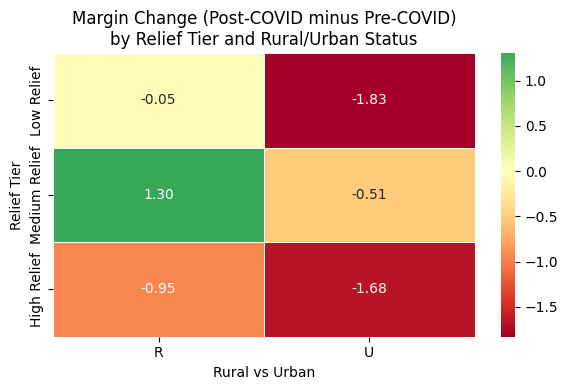

Margin change (Post - Pre) by Relief Tier x Rural/Urban:
Rural Versus Urban     R     U
Relief_Tier                   
Low Relief         -0.05 -1.83
Medium Relief       1.30 -0.51
High Relief        -0.95 -1.68


In [69]:
# Compute Pre-COVID and Post-COVID median margin per group
pre_covid  = df_imputed[df_imputed['COVID Period'] == 'Pre-COVID']
post_covid = df_imputed[df_imputed['COVID Period'] == 'Post-COVID']

# Heatmap A: Margin change by Relief Tier × Rural/Urban
pre_ru  = pre_covid.groupby(['Relief_Tier', 'Rural Versus Urban'],
                             observed=False)['Net Income Margin'].median()
post_ru = post_covid.groupby(['Relief_Tier', 'Rural Versus Urban'],
                              observed=False)['Net Income Margin'].median()
change_ru = (post_ru - pre_ru).unstack('Rural Versus Urban')

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(change_ru, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Margin Change (Post-COVID minus Pre-COVID)\nby Relief Tier and Rural/Urban Status')
ax.set_xlabel('Rural vs Urban')
ax.set_ylabel('Relief Tier')
plt.tight_layout()
plt.show()
print('Margin change (Post - Pre) by Relief Tier x Rural/Urban:')
print(change_ru.round(2))

**Margin Change by Relief Tier and Rural/Urban**

This heatmap shows whether each group's financial position improved or worsened from
the pre-pandemic baseline to the post-COVID period. Positive values (green) mean the
group ended up with a higher median margin than it started; negative values (red) mean
it finished worse off. This directly measures relief effectiveness by controlling for
each group's starting financial health.

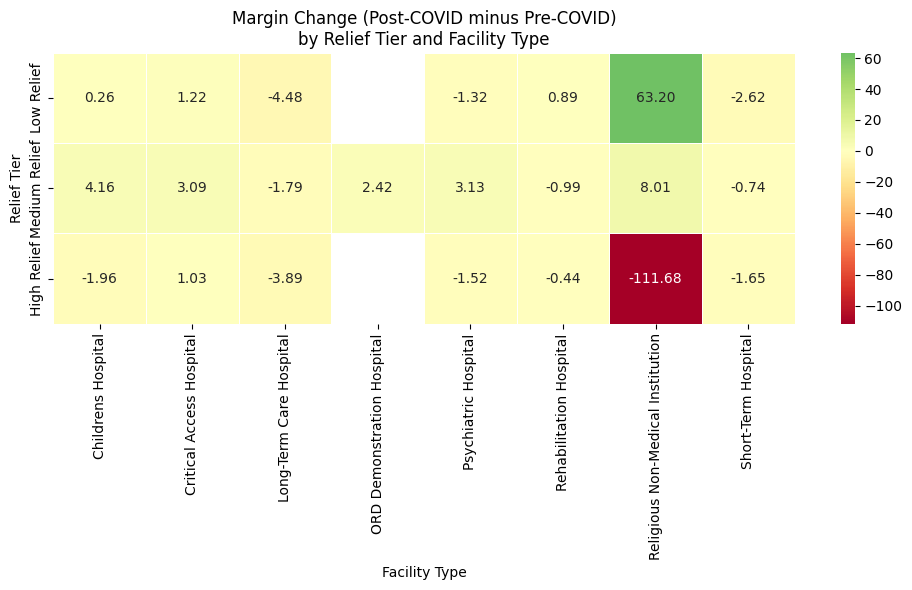


Margin change by Relief Tier x Facility Type:
Facility Type Label  Childrens Hospital  Critical Access Hospital  Long-Term Care Hospital  ORD Demonstration Hospital  Psychiatric Hospital  Rehabilitation Hospital  \
Relief_Tier                                                                                                                                                             
Low Relief                         0.26                      1.22                    -4.48                         NaN                 -1.32                     0.89   
Medium Relief                      4.16                      3.09                    -1.79                        2.42                  3.13                    -0.99   
High Relief                       -1.96                      1.03                    -3.89                         NaN                 -1.52                    -0.44   

Facility Type Label  Religious Non-Medical Institution  Short-Term Hospital  
Relief_Tier                  

In [71]:
# Heatmap B: Margin change by Relief Tier × Facility Type
pre_ft  = pre_covid.groupby(['Relief_Tier', 'Facility Type Label'],
                             observed=False)['Net Income Margin'].median()
post_ft = post_covid.groupby(['Relief_Tier', 'Facility Type Label'],
                              observed=False)['Net Income Margin'].median()
change_ft = (post_ft - pre_ft).unstack('Facility Type Label')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(change_ft, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Margin Change (Post-COVID minus Pre-COVID)\nby Relief Tier and Facility Type')
ax.set_xlabel('Facility Type')
ax.set_ylabel('Relief Tier')
plt.tight_layout()
plt.show()
print('\nMargin change by Relief Tier x Facility Type:')
print(change_ft.round(2))

**Margin Change by Relief Tier and Facility Type**

Breaking down the margin change by facility type reveals whether certain hospital
categories recovered better within each relief tier. CAHs and Short-Term hospitals
are the most policy-relevant groups given their role in rural healthcare access.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_852\1671186341.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Relief_Tier", "Rural Versus Urban"])["Net Income Margin"]
C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_852\1671186341.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Relief_Tier", "Rural Versus Urban"])["Net Income Margin"]
C:\Users\Avnish Jadhav\AppData\Local\Temp\ipykernel_852\1671186341.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior o

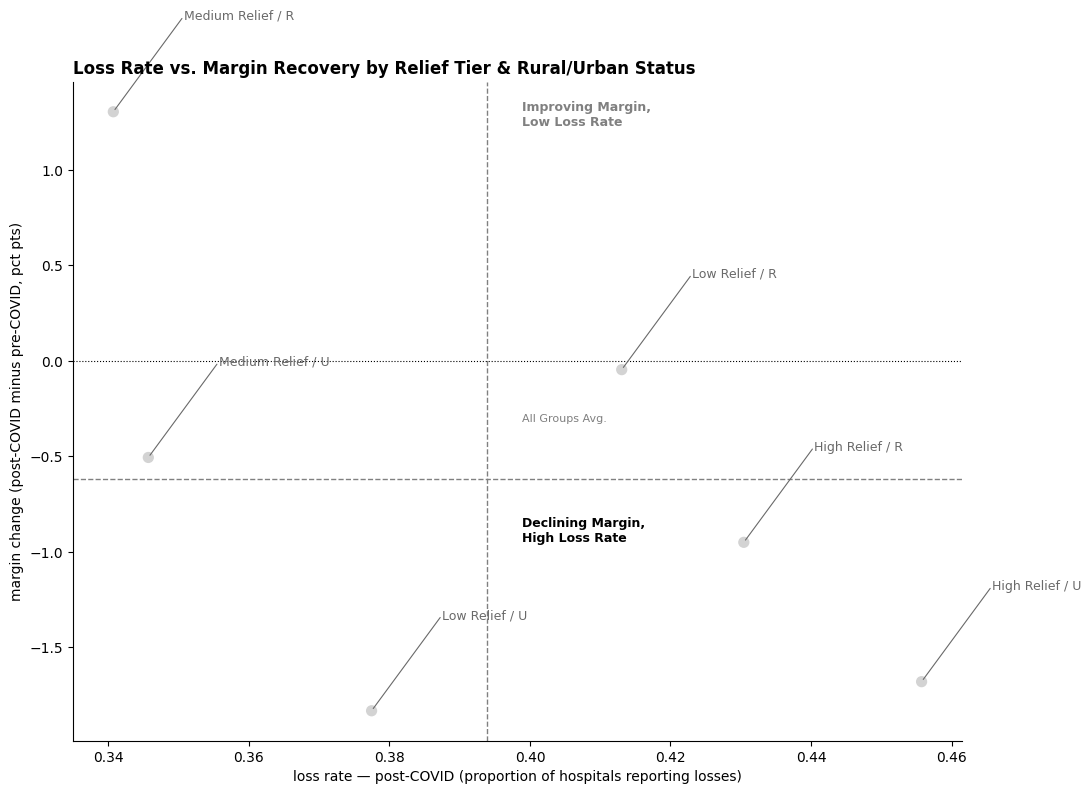

In [ ]:
pre_med = (
    df_imputed[df_imputed["COVID Period"] == "Pre-COVID"]
    .groupby(["Relief_Tier", "Rural Versus Urban"])["Net Income Margin"]
    .median()
    .rename("margin_pre")
)
post_med = (
    df_imputed[df_imputed["COVID Period"] == "Post-COVID"]
    .groupby(["Relief_Tier", "Rural Versus Urban"])["Net Income Margin"]
    .median()
    .rename("margin_post")
)
loss_rate = (
    df_imputed[df_imputed["COVID Period"] == "Post-COVID"]
    .groupby(["Relief_Tier", "Rural Versus Urban"])["Loss"]
    .mean()
    .rename("loss_rate")
)

summary2 = pd.concat([pre_med, post_med, loss_rate], axis=1).reset_index()
summary2["margin_change"] = summary2["margin_post"] - summary2["margin_pre"]
summary2["Group Label"] = summary2["Relief_Tier"].astype(str) + " / " + summary2["Rural Versus Urban"].astype(str)

fig, ax = plt.subplots(figsize=(11, 8))

avg_loss   = summary2["loss_rate"].mean()
avg_change = summary2["margin_change"].mean()

ax.axhline(y=avg_change, color="gray", linewidth=1, linestyle="--")
ax.axvline(x=avg_loss,   color="gray", linewidth=1, linestyle="--")
ax.axhline(y=0, color="black", linewidth=0.8, linestyle=":")   

highlight = ["Low Relief / Rural", "Low Relief / Urban"]
colors    = ["red"       if g in highlight else "lightgray" for g in summary2["Group Label"]]
sizes     = [80          if g in highlight else 50          for g in summary2["Group Label"]]

ax.scatter(summary2["loss_rate"], summary2["margin_change"],
           color=colors, s=sizes, zorder=3)

offsets = {
    "Low Relief / Rural":    ( 0.01,  -0.8),
    "Low Relief / Urban":    ( 0.01,   0.5),
    "Medium Relief / Rural": (-0.07,  -0.8),
    "Medium Relief / Urban": (-0.07,   0.5),
    "High Relief / Rural":   ( 0.01,  -0.8),
    "High Relief / Urban":   ( 0.01,   0.5),
}

for _, row in summary2.iterrows():
    label  = row["Group Label"]
    dx, dy = offsets.get(label, (0.01, 0.5))
    color  = "red" if label in highlight else "dimgray"
    text_x = row["loss_rate"]    + dx
    text_y = row["margin_change"] + dy
    ax.annotate("",
                xy=(row["loss_rate"], row["margin_change"]),
                xytext=(text_x, text_y),
                arrowprops=dict(arrowstyle="-", color=color, linewidth=0.8))
    ax.text(text_x, text_y, label, fontsize=9, color=color, va="center")

ax.annotate("All Groups Avg.",
            xy=(avg_loss, avg_change),
            xytext=(avg_loss + 0.005, avg_change + 0.3),
            fontsize=8, color="gray")

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

ax.text(avg_loss + 0.005, ymax - 0.1,
        "Improving Margin,\nLow Loss Rate",
        fontsize=9, color="gray", fontweight="bold", va="top")
ax.text(avg_loss + 0.005, avg_change - 0.2,
        "Declining Margin,\nHigh Loss Rate",
        fontsize=9, color="black", fontweight="bold", va="top")

ax.set_xlabel("loss rate — post-COVID (proportion of hospitals reporting losses)", fontsize=10)
ax.set_ylabel("margin change (post-COVID minus pre-COVID, pct pts)",               fontsize=10)
ax.set_title("Loss Rate vs. Margin Recovery by Relief Tier & Rural/Urban Status",
             fontweight="bold", loc="left", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()